# Fragrance Market Intelligence — Results

This notebook assembles evidence already produced by the pipeline scripts
(`01_clean.py` through `07_figures.py`, plus `03b_cluster_selection.py`). It
performs no computation of its own: every cell loads a saved
`data/interim/*.parquet` or `outputs/*.csv` file, or displays a saved PNG.
Family labels use the short names in `outputs/cluster_names_final.csv`
throughout — never a bare cluster number or the long auto-generated
slash-name.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

IN_DIR = Path("../data/interim")
OUT_DIR = Path("../outputs")
FIG_DIR = OUT_DIR / "figures"

Family labels come from `cluster_names_final.csv` (the reviewed short names),
not the auto-generated names baked into the pipeline's intermediate files.
`attach_family` below is the one place that mapping happens; every later
table calls it instead of showing a raw cluster id.

In [2]:
names = pd.read_csv(OUT_DIR / "cluster_names_final.csv")
names = names.rename(columns={"#": "cluster", "Short name": "family"})[["cluster", "family"]]
FAMILY = dict(zip(names["cluster"], names["family"]))

def attach_family(df, col="cluster"):
    out = df.copy()
    if "cluster_name" in out.columns:
        out = out.drop(columns=["cluster_name"])
    fam = out.pop(col).map(FAMILY)
    out.insert(0, "Family", fam)
    return out

def show(df):
    display(df.round(3))

Every checkpoint used anywhere below is loaded once here and listed with its
row/column count, so the full evidence base — what exists and how big it is
— is visible before any result is shown.

In [3]:
paths = {
    "01_products": IN_DIR / "01_products.parquet",
    "01_notes_long": IN_DIR / "01_notes_long.parquet",
    "01_accords_long": IN_DIR / "01_accords_long.parquet",
    "01_ai_summary_long": IN_DIR / "01_ai_summary_long.parquet",
    "03_product_family": IN_DIR / "03_product_family.parquet",
    "04_family_demand": IN_DIR / "04_family_demand.parquet",
    "05_family_sentiment": IN_DIR / "05_family_sentiment.parquet",
    "05b_family_season": IN_DIR / "05b_family_season.parquet",
    "06_family_share_by_year": IN_DIR / "06_family_share_by_year.parquet",
    "06_territory_scores": OUT_DIR / "06_territory_scores.csv",
    "taxonomy_map": OUT_DIR / "taxonomy_map.csv",
    "taxonomy_validation": OUT_DIR / "taxonomy_validation.csv",
    "note_normalisation": OUT_DIR / "note_normalisation.csv",
    "cluster_algorithm_comparison": OUT_DIR / "cluster_algorithm_comparison.csv",
    "cluster_names_final": OUT_DIR / "cluster_names_final.csv",
}
data = {n: (pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)) for n, p in paths.items()}
manifest = pd.DataFrame([{"artefact": n, "rows": len(data[n]), "cols": data[n].shape[1]} for n in paths])
show(manifest)

,artefact,rows,cols
0,01_products,131930,30
1,01_notes_long,1098223,3
2,01_accords_long,1000570,3
3,01_ai_summary_long,210521,5
4,03_product_family,103492,4
5,04_family_demand,15,19
6,05_family_sentiment,15,7
7,05b_family_season,15,7
8,06_family_share_by_year,531,4
9,06_territory_scores,15,20


## 1. Data and population

The pipeline filters 131,930 scraped products down to a 32,499-product
analysis population, on three conditions: at least one surviving note, a
launch year between 1990 and 2025, and enough community raters to trust the
rating. The table below is the comparison across candidate rater thresholds
that the 50-rater cutoff was chosen from.

In [4]:
p = data["01_products"]
YEAR_MIN, YEAR_MAX = 1990, 2025
base = p[(p["n_notes"] >= 1) & p["year"].between(YEAR_MIN, YEAR_MAX)]

rows = []
for label, thr in [("no threshold", None), (20, 20), (50, 50), (100, 100), (200, 200)]:
    sub = base if thr is None else base[base["people"] >= thr]
    rows.append({"people >=": label, "rows": len(sub),
                 "% with ai_summary": 100 * sub["has_ai_summary"].mean(),
                 "distinct brands": sub["brand"].nunique()})
show(pd.DataFrame(rows))

,people >=,rows,% with ai_summary,distinct brands
0,no threshold,99683,11.693,6784
1,20,47126,24.710,3354
2,50,32499,35.629,2261
3,100,22669,49.182,1618
4,200,14687,67.590,1101


The waterfall below shows how much each of the three filters removes, in the
order they're applied, ending at the 32,499 products used everywhere else in
this notebook.

In [5]:
n_total = len(p)
n_has_note = int((p["n_notes"] >= 1).sum())
n_year_ok = int(((p["n_notes"] >= 1) & p["year"].between(YEAR_MIN, YEAR_MAX)).sum())
n_final = int(p["in_population"].sum())

funnel = pd.DataFrame({
    "step": ["all scraped products", "+ has >= 1 note", "+ year 1990-2025", "+ people >= 50 (final)"],
    "rows remaining": [n_total, n_has_note, n_year_ok, n_final],
})
show(funnel)

,step,rows remaining
0,all scraped products,131930
1,+ has >= 1 note,129388
2,+ year 1990-2025,99683
3,+ people >= 50 (final),32499


The same funnel as a chart, for a quicker read of how much each step costs
relative to the others.

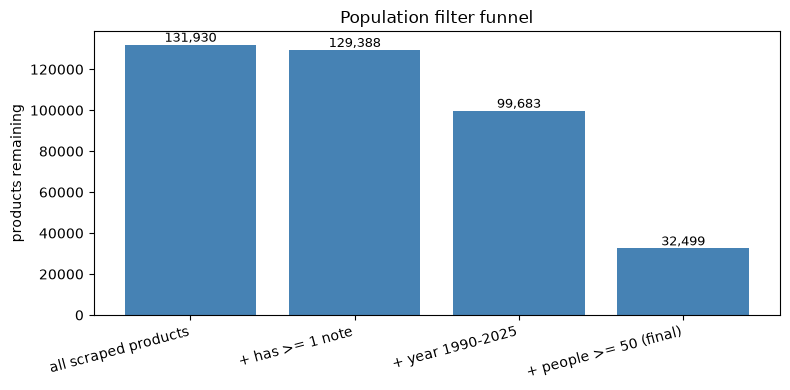

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(funnel["step"], funnel["rows remaining"], color="steelblue")
for i, v in enumerate(funnel["rows remaining"]):
    ax.text(i, v + 1500, f"{v:,}", ha="center", fontsize=9)
ax.set_ylabel("products remaining")
ax.set_title("Population filter funnel")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

Sentiment (section 6) only uses products that also have a Fragrantica AI
summary — 35.6% of the population. The table compares that subpopulation
against the full population it's drawn from: it skews toward more-rated,
slightly newer, slightly higher-rated products, since AI summaries are
concentrated on popular products.

In [7]:
pop = p[p["in_population"]]
subpop = pop[pop["has_ai_summary"]]
compare = pd.DataFrame({
    "full population": [len(pop), pop["people"].mean(), pop["year"].mean(), pop["rating_avg"].mean()],
    "sentiment subpopulation": [len(subpop), subpop["people"].mean(), subpop["year"].mean(), subpop["rating_avg"].mean()],
}, index=["n products", "mean people", "mean year", "mean rating"])
show(compare)

,full population,sentiment subpopulation
n products,32499.000,11579.000
mean people,577.089,1331.731
mean year,2015.819,2016.880
mean rating,3.961,4.002


## 2. Note normalisation

Raw note text on the population reduces to 2,029 distinct tokens after basic
string cleanup (lowercasing, whitespace, hyphens, parenthetical glosses).
Each token was then kept, merged into a synonym group, or dropped as a
category placeholder or too rare to matter. The counts below are the result
of that pass.

In [8]:
nn = data["note_normalisation"]
show(nn["action"].value_counts().rename("n raw tokens").to_frame())
print(f"raw tokens: {len(nn):,}  ->  canonical notes surviving: {nn['canonical'].nunique():,}")

,n raw tokens
action,
DROP_RARE,1327
KEEP,492
MERGE,188
DROP_PLACEHOLDER,22


raw tokens: 2,029  ->  canonical notes surviving: 492


What a "merge" looks like in practice: the 20 largest synonym groups, e.g.
spelling variants, plurals, and part-of-plant qualifiers folded into one
canonical note. These feed directly into the taxonomy in section 3.

In [9]:
merges = nn[nn["action"] == "MERGE"]
groups = merges.groupby("canonical")["raw_token"].apply(list)
sample = groups.loc[groups.str.len().sort_values(ascending=False).index[:20]]
show(pd.DataFrame({"canonical note": sample.index, "merged variants": sample.values}))

,canonical note,merged variants
0,lemon,"[lemon zest, lemon peel, lemon leaf, lemon tree, lemon balm, lemonade, lemon leaf oil, lemon sod..."
1,apple,"[apple tree, apple tree blossom, apple leaf, apple pie, apple pulp, applejack]"
2,orange,"[orange peel, orange oil, orange leaf, orangewood, orange soda]"
3,vanilla,"[vanila, vanilla bean, vanilla flower, vanilla pod, vanilla leaves]"
4,black currant,"[blackcurrant, black currant leaf, black currant blossom, blackcurrant juice]"
5,amber,"[ambertonic, amber oil, ambermax™, amberever]"
6,strawberry,"[strawberry leaf, strawberry s’mores, strawberry flower, strawberry jam]"
7,grapefruit,"[grapefruit blossom, graperfuit, grapefruit leaf, grapefruit peel]"
8,sandalwood,"[sandalowood, sandal, sandalwood flower, sandalore™]"
9,pistachio,"[pistachio blossom, pistachio leaf, pistachio liquer]"


A handful of merge/un-merge decisions were set by hand rather than by the
automated rule, after spot-checking flagged false positives (e.g. automated
matching wanted to fold "ambergris" into "amber", and "clover" into "clove").
Every row below carries its reasoning in the `reason` column.

In [10]:
overrides = nn[nn["reason"].str.contains("manual override", na=False)]
show(overrides[["raw_token", "canonical", "action", "reason"]])

,raw_token,canonical,action,reason
3,amber,amber,KEEP,"manual override: ambergris is animalic, a different material from the amber accord (vs 'ambergri..."
11,mandarin orange,mandarin,MERGE,manual override: promoted from REVIEW
45,ambergris,ambergris,KEEP,"manual override: ambergris is animalic, a different material from the amber accord (vs 'amber')"
60,virginia cedar,cedar,MERGE,manual override: promoted from REVIEW
111,amberwood,amberwood,KEEP,"manual override: amberwood is a distinct woody material, not a spelling variant of amber (vs 'am..."
130,strawberry,strawberry,KEEP,manual override: straw (dried grass) is a different material from the strawberry fruit (vs 'stra...
134,mango,mango,KEEP,manual override: mangosteen is a botanically unrelated fruit despite the name (vs 'mangosteen');...
415,clover,clover,KEEP,"manual override: clover is a different plant/flower, not a spelling variant of clove (vs 'clove'..."


## 3. Taxonomy

Canonical notes were grouped into 15 families by co-occurrence across
products — never by note *name* or by perfumery knowledge hard-coded into
the grouping. The map below is a 2-D projection of that co-occurrence
structure: notes that sit near each other tend to appear together on the
same products, and colour marks the family a note was assigned to.

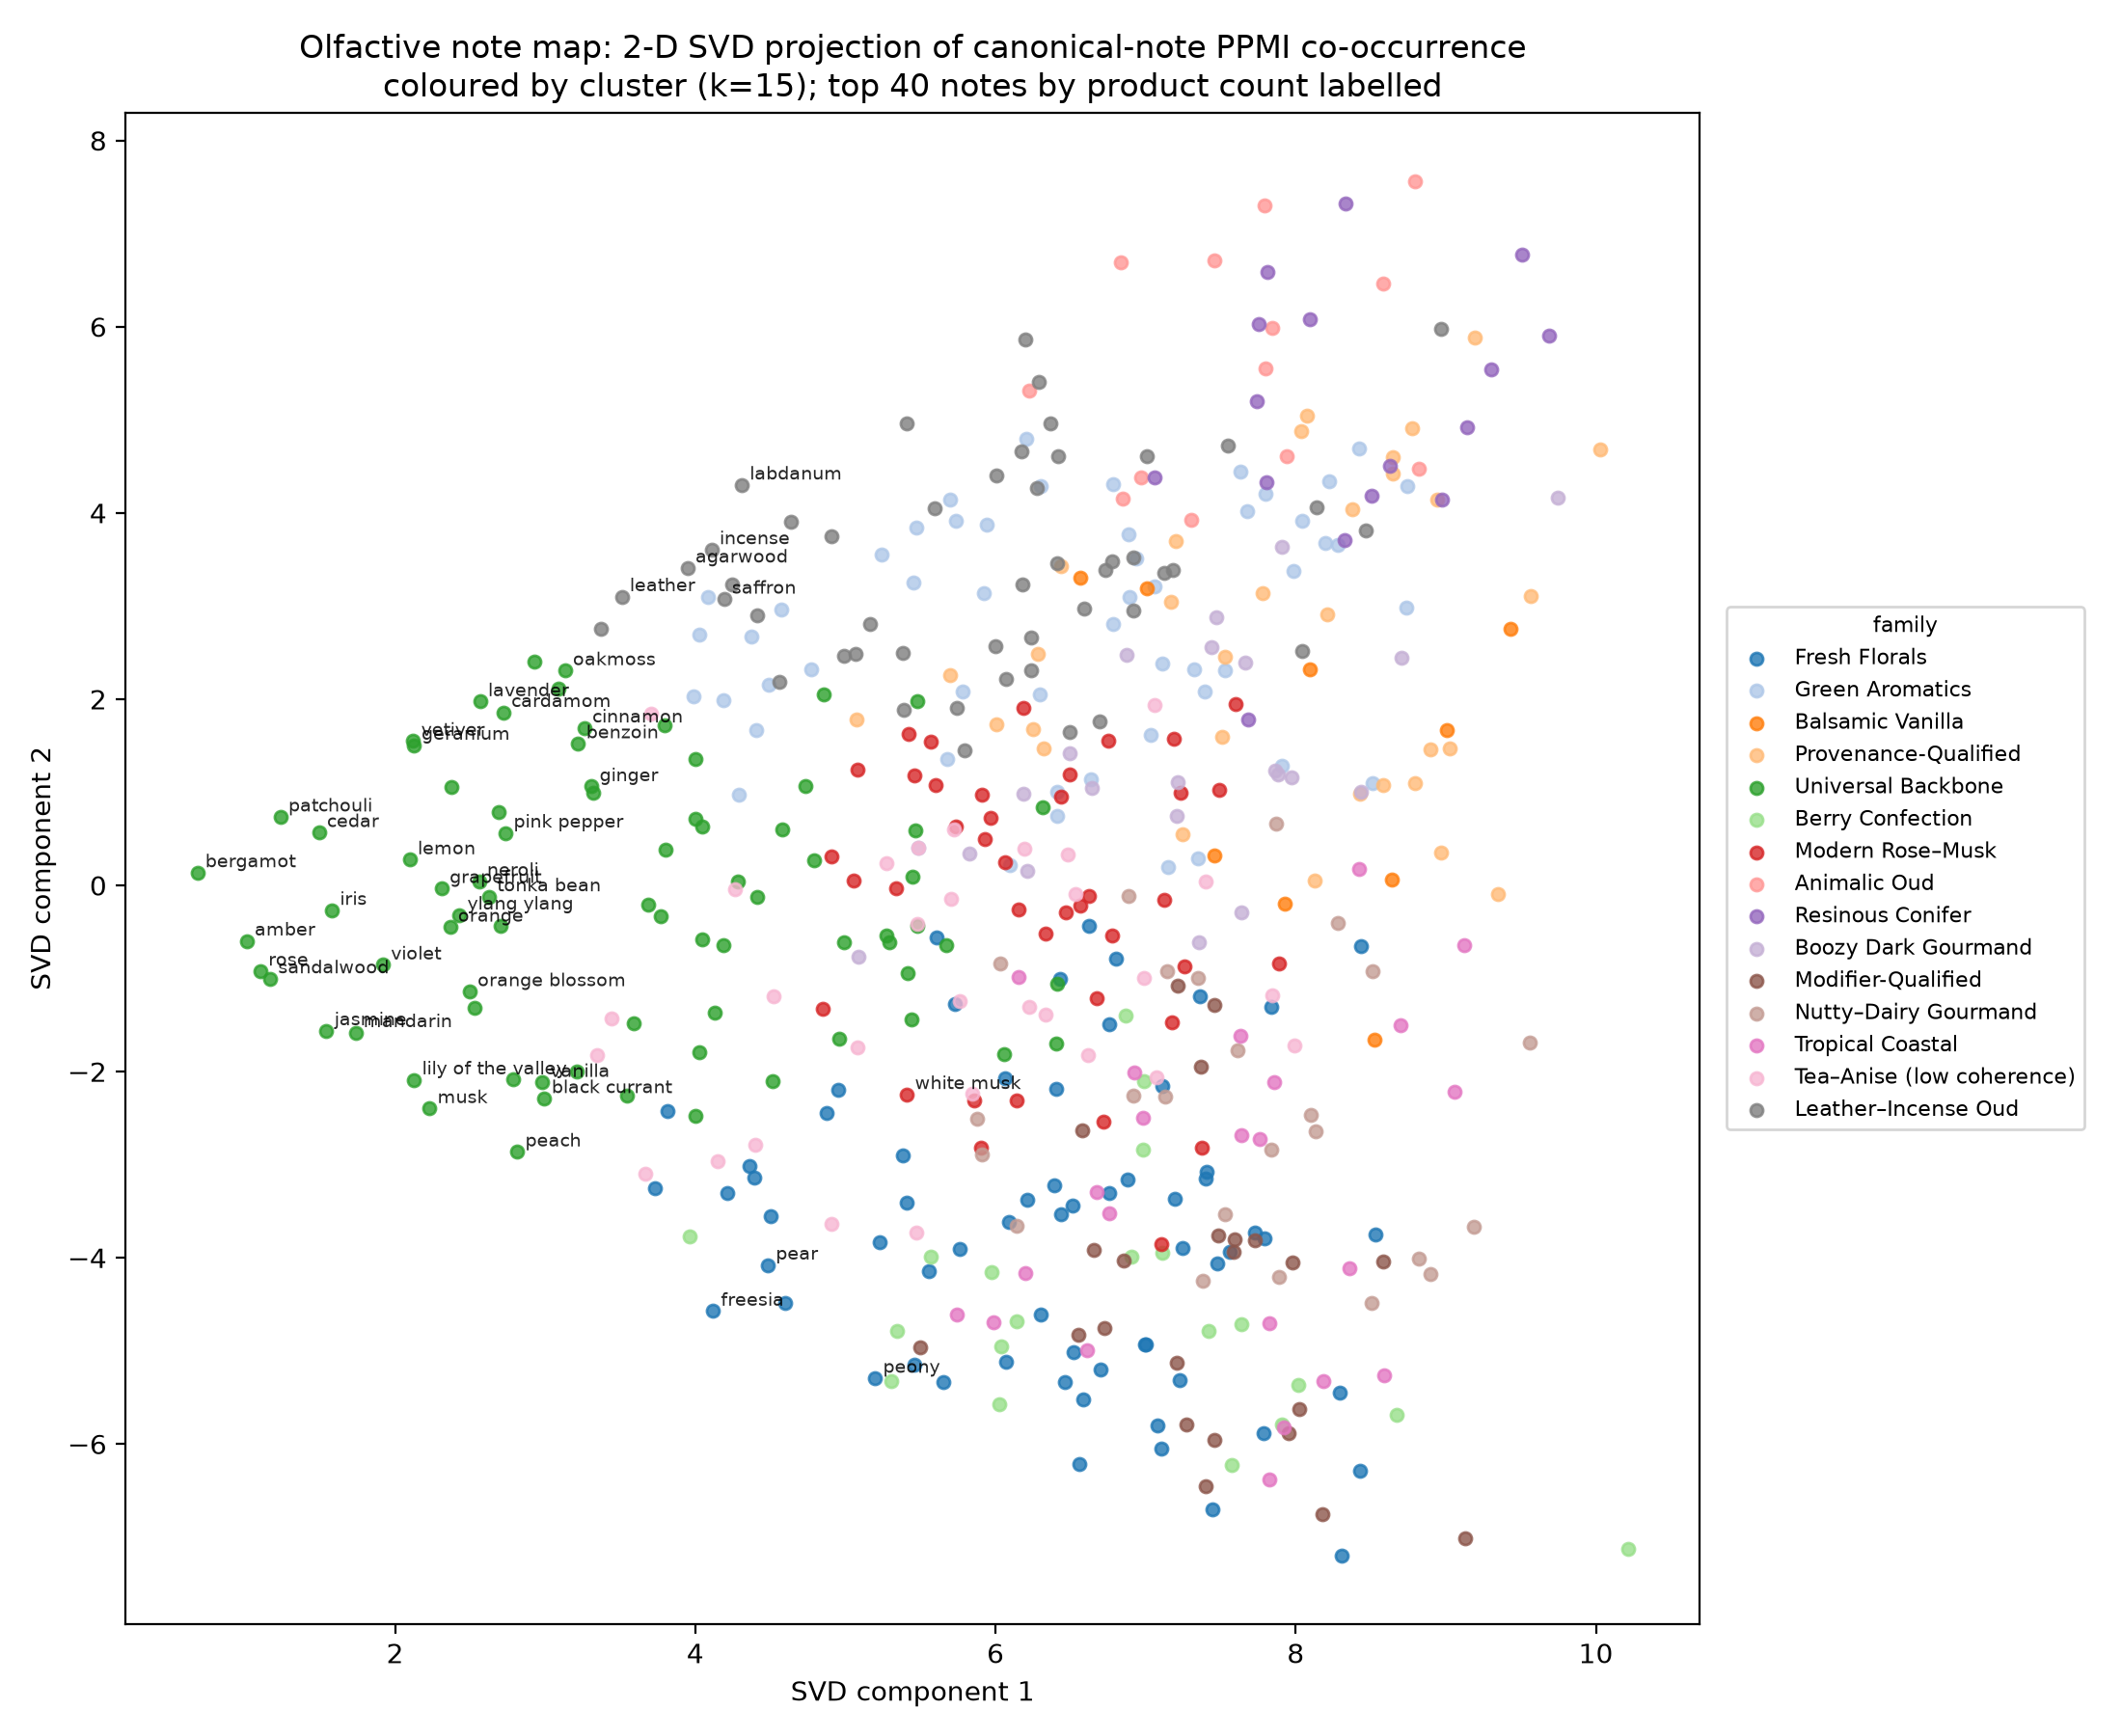

In [11]:
display(Image(filename=str(FIG_DIR / "a_note_map.png")))

One row per family: how many canonical notes it contains, its most
representative notes by product count, and the three Fragrantica accords
most over-represented among its products (lift over the population base
rate) — the accords are the external check that a learned grouping
corresponds to something real, not an artefact of the clustering.

In [12]:
sizes = data["taxonomy_map"].groupby("cluster").size().rename("notes in family")
top_notes = pd.read_csv(OUT_DIR / "cluster_names.csv").set_index("cluster")["top_notes"]

val = data["taxonomy_validation"]
top3 = (val[val["rank"] <= 3].sort_values(["cluster", "rank"])
        .groupby("cluster")
        .apply(lambda g: ", ".join(f"{a} ({l:.1f}x)" for a, l in zip(g["accord"], g["lift"]))))

fam_table = pd.DataFrame({"notes in family": sizes, "top notes": top_notes, "top accords (lift)": top3})
show(attach_family(fam_table.reset_index()))

,Family,notes in family,top notes,top accords (lift)
0,Fresh Florals,64,"freesia, pear, peony, magnolia, gardenia, orchid, lily, mimosa","sour (2.7x), aquatic (2.4x), tropical (2.0x)"
1,Green Aromatics,53,"mint, sage, petitgrain, basil, rosemary, cypress, clary sage, galbanum","camphor (5.4x), cannabis (4.4x), bitter (3.9x)"
2,Balsamic Vanilla,9,"bourbon vanilla, peru balsam, tolu balsam, vanilla absolute, ebony wood, skin, night blooming ja...","balsamic (3.1x), rum (2.8x), mineral (2.1x)"
3,Provenance-Qualified,32,"madagascar vanilla, haitian vetiver, calabrian bergamot, egyptian jasmine, sicilian lemon, indon...","tuberose (1.8x), earthy (1.6x), balsamic (1.3x)"
4,Universal Backbone,76,"musk, bergamot, sandalwood, vanilla, jasmine, amber, patchouli, cedar","soapy (1.2x), lavender (1.2x), tuberose (1.2x)"
5,Berry Confection,20,"raspberry, praline, sugar, red berries, strawberry, cherry, whipped cream, marshmallow","cherry (6.9x), sour (6.9x), lactonic (3.3x)"
6,Modern Rose–Musk,40,"white musk, ambroxan, ambrette, bulgarian rose, turkish rose, amberwood, damask rose, blood orange","rose (1.9x), musky (1.6x), ozonic (1.4x)"
7,Animalic Oud,13,"castoreum, civet, champaca, animal notes, indian oud, cambodian oud, turmeric, laotian oud","oud (5.2x), animalic (4.7x), smoky (4.1x)"
8,Resinous Conifer,16,"immortelle, balsam fir, chamomile, smoke, hay, beeswax, fir, broom","conifer (8.5x), herbal (5.2x), camphor (4.6x)"
9,Boozy Dark Gourmand,21,"honey, coffee, rum, cacao, oak, davana, dark chocolate, cognac","whiskey (10.6x), rum (10.6x), cacao (9.7x)"


## 4. Model selection: why k=15

This section is diagnostic evidence for the choice of 15 clusters, gathered
once in `03b_cluster_selection.py` and only displayed here. **Stated
plainly: no single criterion identifies a decisive k.** Inertia, silhouette,
Calinski-Harabasz and Davies-Bouldin all move smoothly with no sharp elbow
past k≈8-10 (an automated knee detector on the inertia curve lands on
k=13 — close to, not confirming, 15).

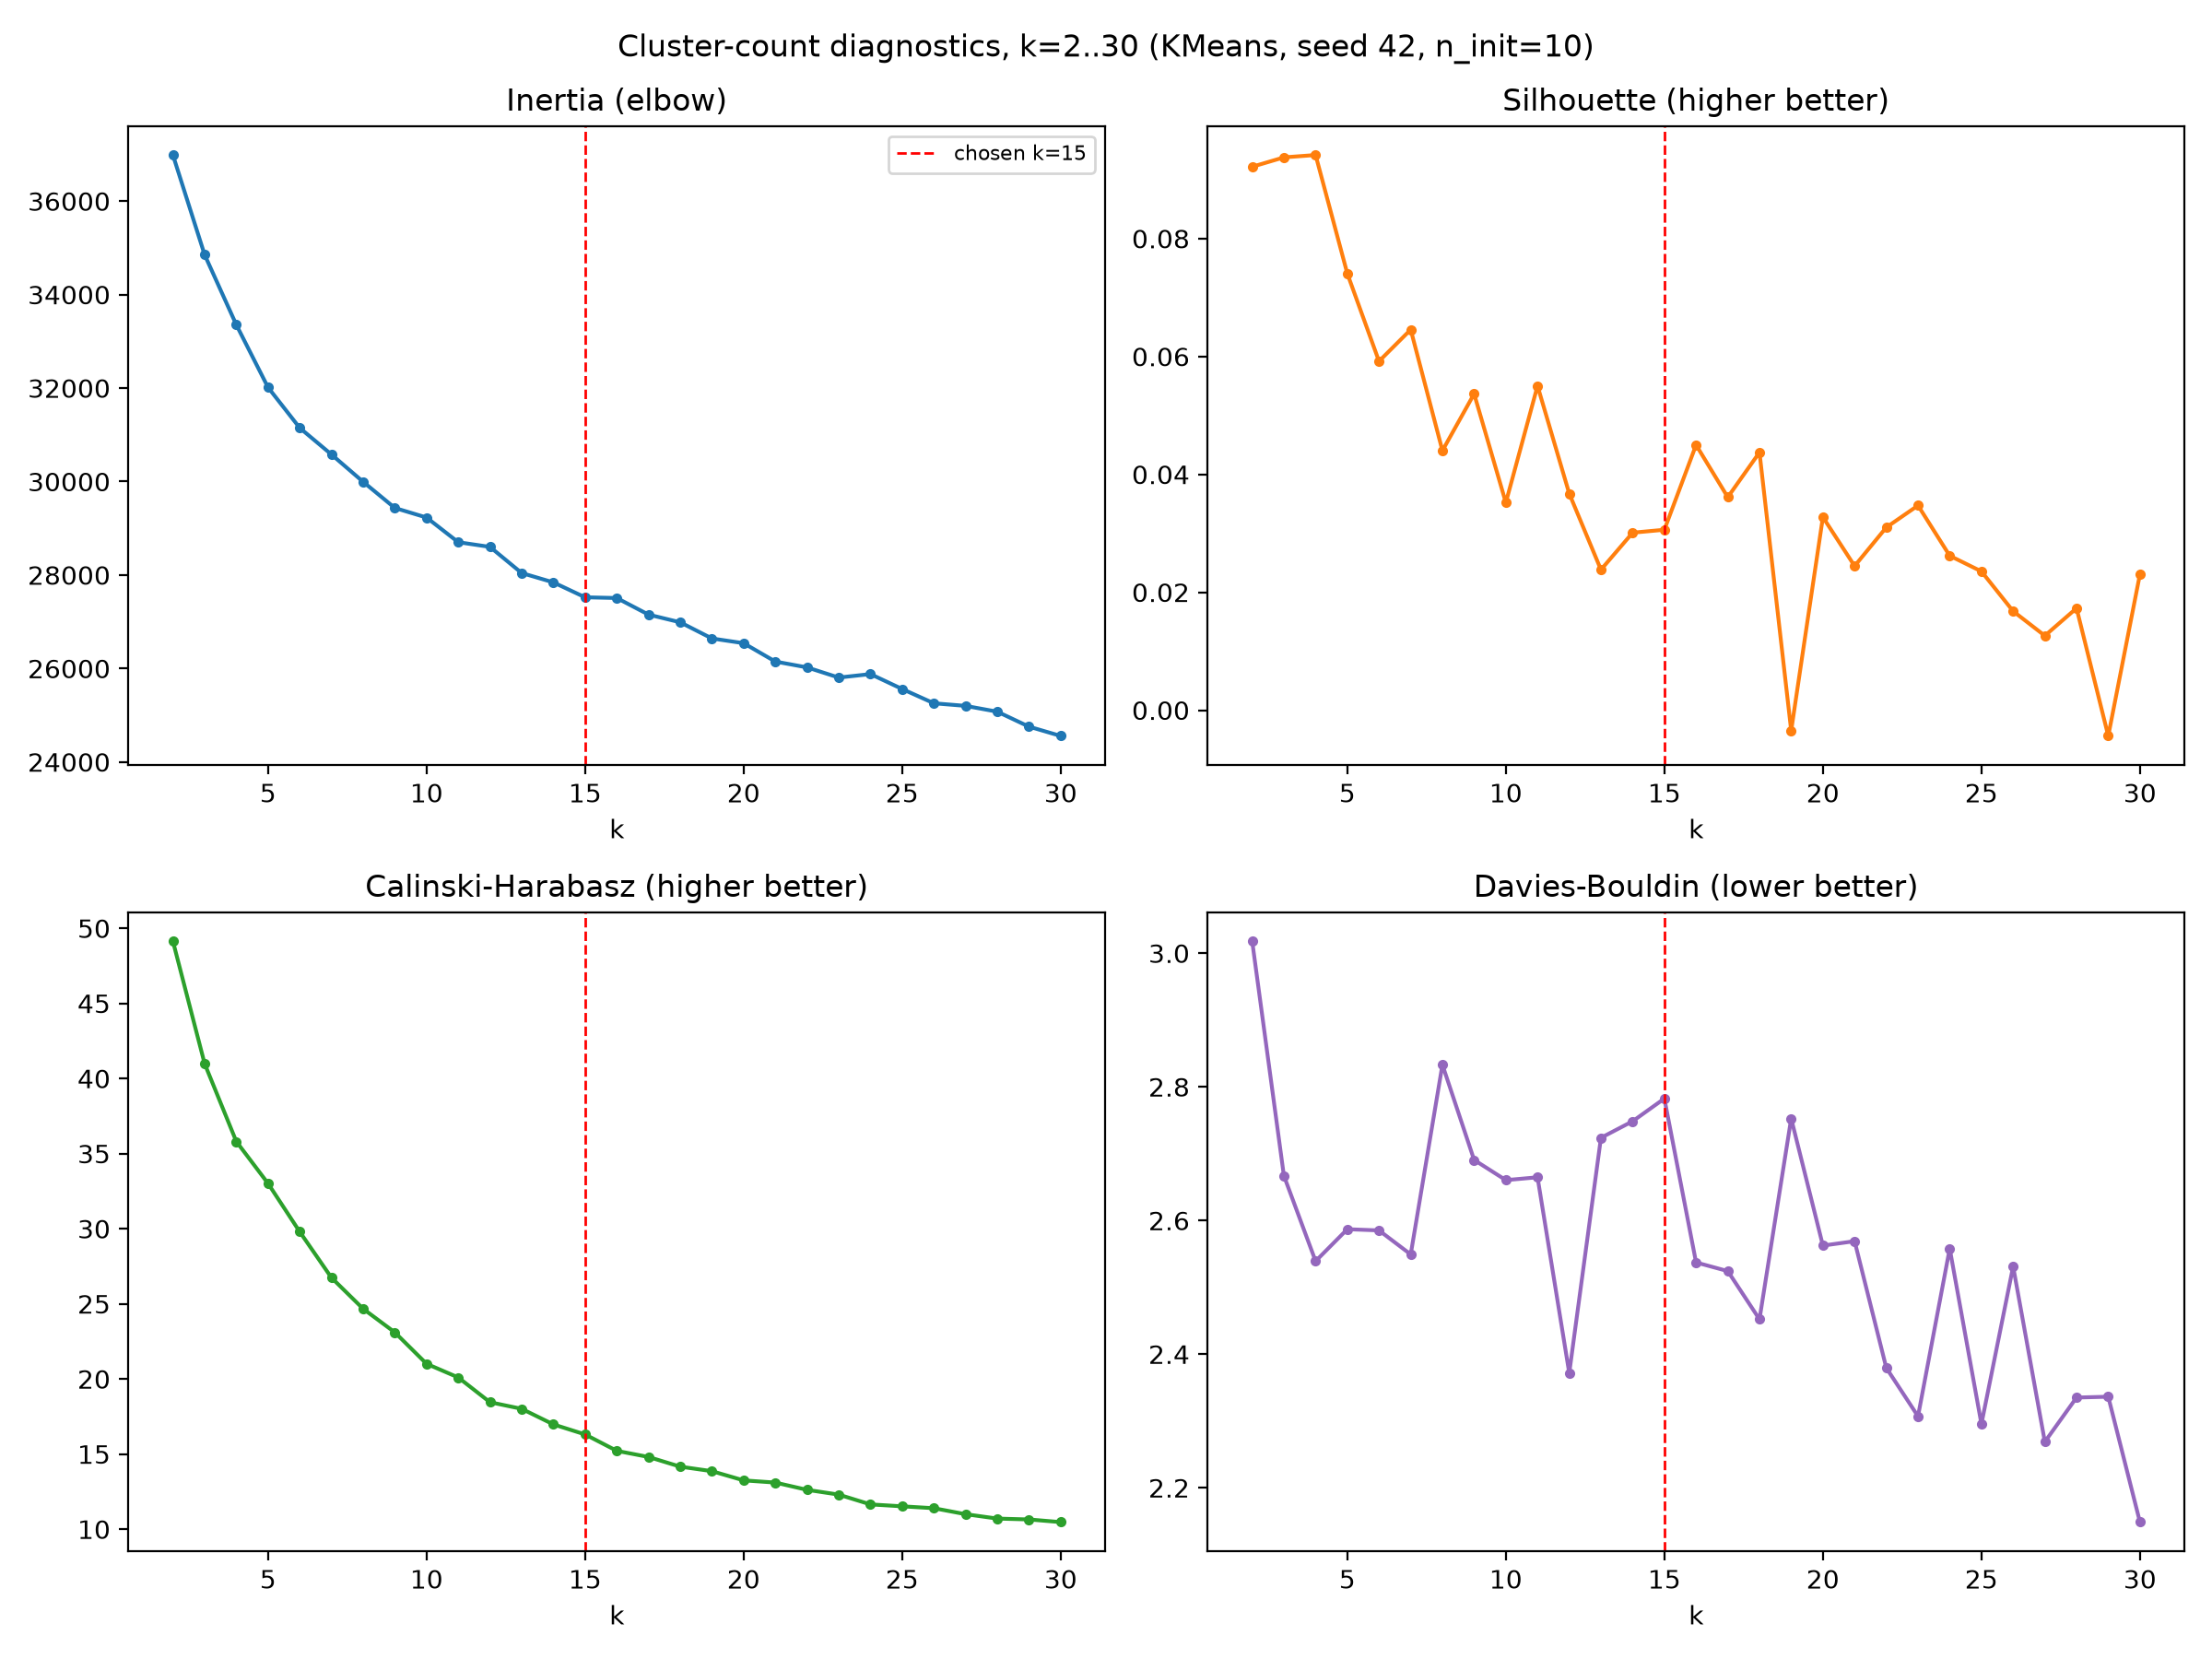

In [13]:
display(Image(filename=str(FIG_DIR / "d_cluster_selection.png")))

Bootstrap stability — how much a random resample of the products changes the
resulting clusters — declines steadily from k=8 to k=25 with no plateau or
step change. k=15 sits partway down that decline, not at a point where
stability breaks or recovers.

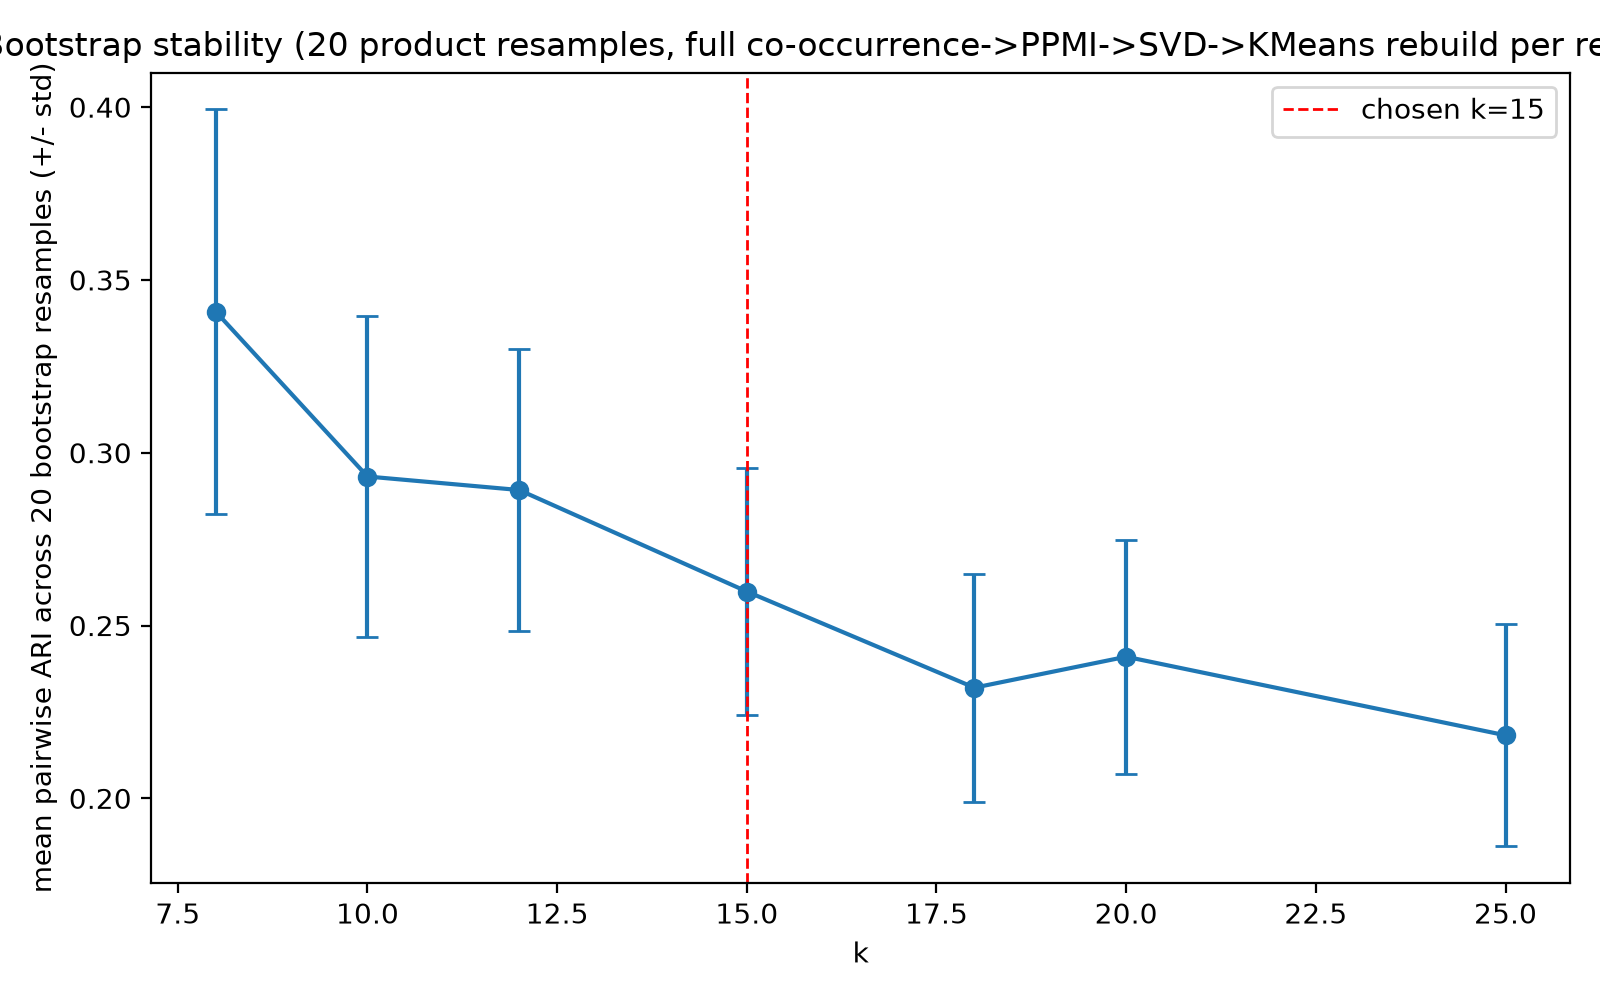

In [14]:
display(Image(filename=str(FIG_DIR / "e_cluster_stability.png")))

Agreement with each note's dominant Fragrantica accord (Adjusted Mutual
Information) is the one external-validity signal in this section, and it
happens to peak at k=15 among the values tested — the main evidence in
15's favour.

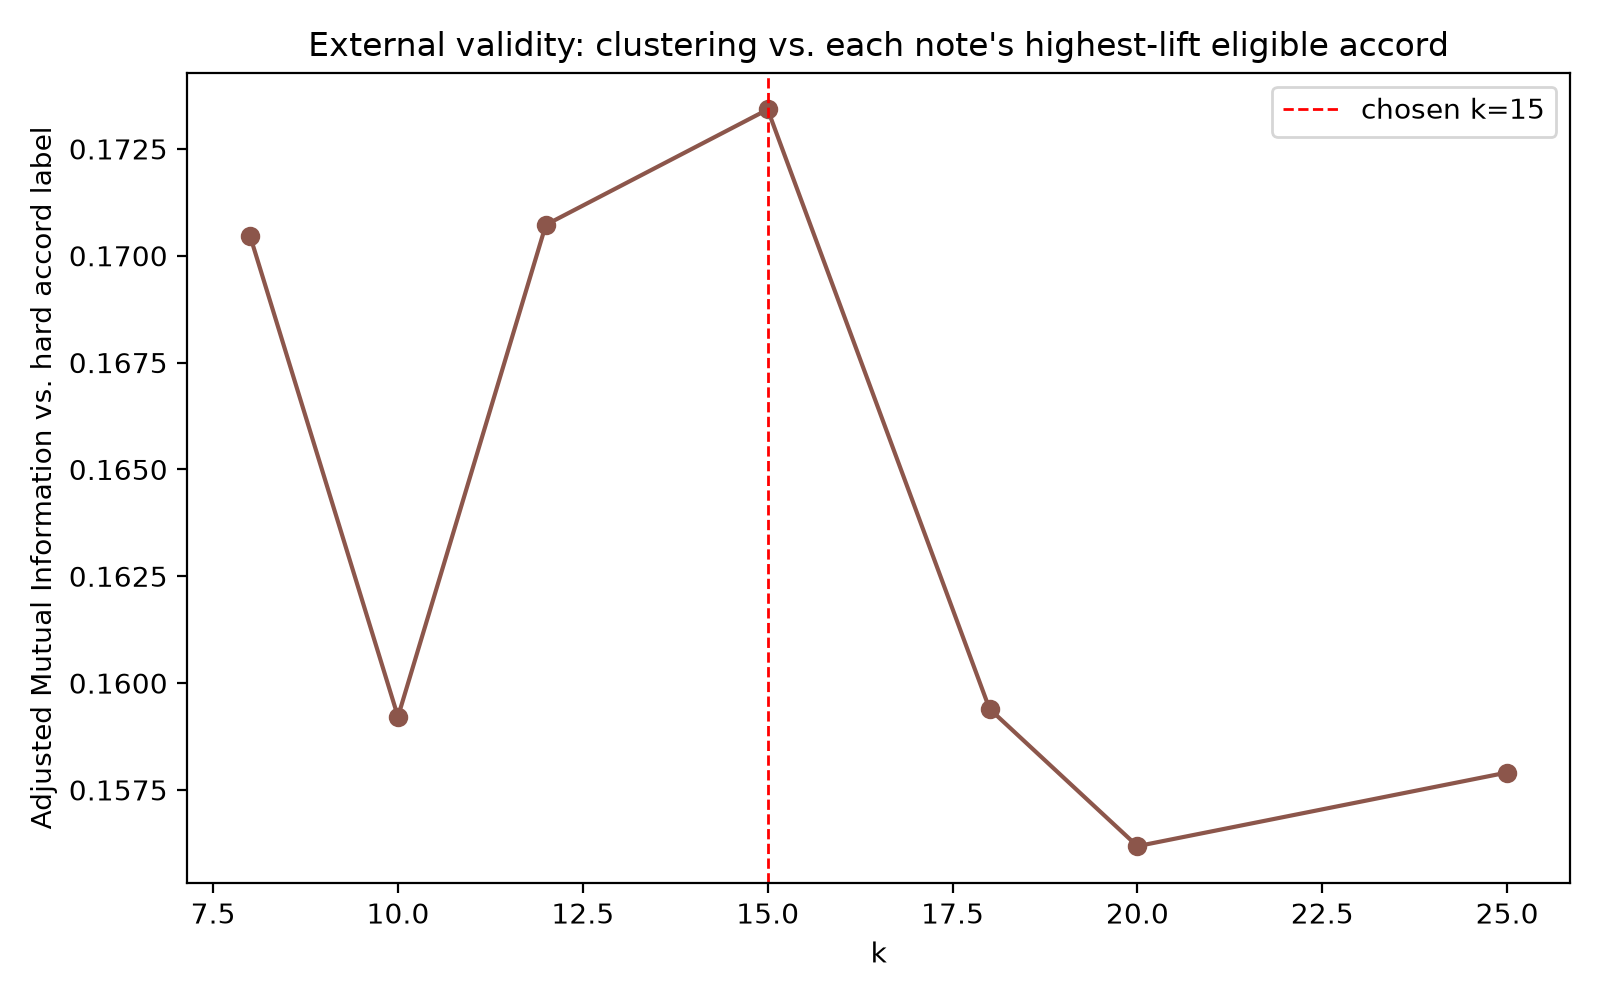

In [15]:
display(Image(filename=str(FIG_DIR / "g_ami_vs_k.png")))

HDBSCAN — which only forms a cluster where the data is genuinely dense —
finds **100% noise** at min_cluster_size 10 and 20 (see the comparison table
below), meaning there is no density-based structure to recover at that
scale. The dendrogram shows the same picture from a hierarchical angle: no
obvious cut point stands out from the merge heights.

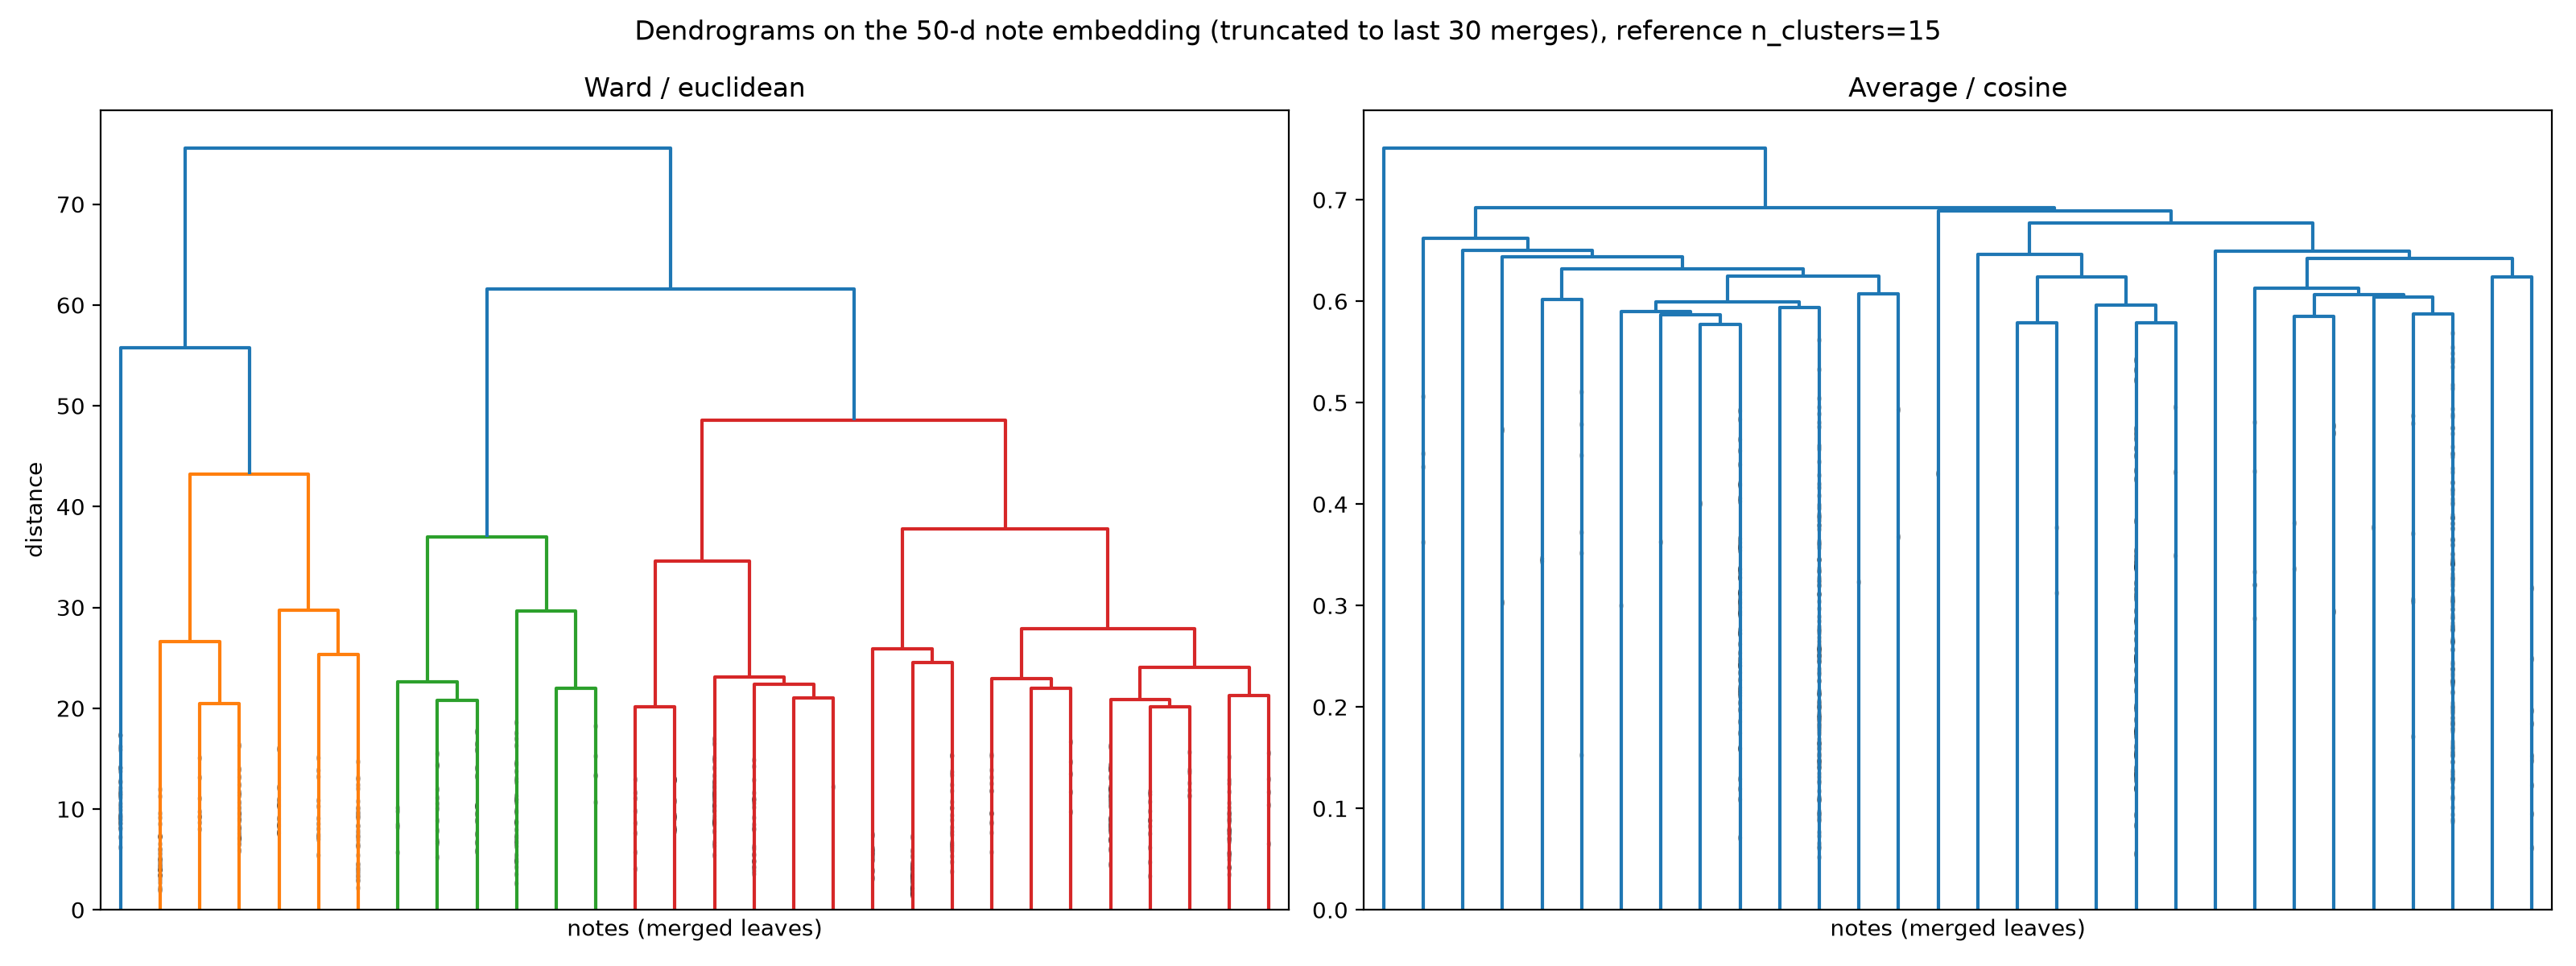

In [16]:
display(Image(filename=str(FIG_DIR / "f_dendrogram.png")))

Together this says the note-embedding space is closer to a continuum than a
set of natural islands: **k=15 is a chosen discretisation of that
continuum, justified by external agreement and interpretability, not by any
one index finding it optimal.** The table below is every alternative
algorithm tried at k=15, cross-checked against the KMeans partition actually
used.

In [17]:
show(data["cluster_algorithm_comparison"])

,algorithm,param,n_clusters_found,ari_vs_kmeans15,ami_vs_accords,pct_noise,silhouette
0,agglomerative_ward,euclidean/ward,15,0.336,0.168,0.000,-0.007
1,agglomerative_cosine_average,cosine/average,15,0.165,0.150,0.000,0.012
2,hdbscan_mcs5,min_cluster_size=5,2,-0.002,0.032,0.921,0.328
3,hdbscan_mcs10,min_cluster_size=10,0,0.000,0.000,1.000,NaN
4,hdbscan_mcs20,min_cluster_size=20,0,0.000,0.000,1.000,NaN
5,gmm_full,covariance=full,15,0.501,0.177,0.000,0.032
6,gmm_diag,covariance=diag,15,0.204,0.087,0.000,-0.015
7,spectral_cooccurrence,affinity=co-occurrence,15,0.228,0.099,0.000,0.027


## 5. Demand

Four signals per family, computed separately and never blended into one
number: approval (Bayesian-shrunk rating), desire (share of collection
interest that is "want" rather than "have/had"), adoption (log collection
size), and value perception. Raw and brand-demeaned versions sit side by
side — demeaned removes each brand's average level, isolating family-level
preference from brand-prestige halo.

In [18]:
d4 = data["04_family_demand"]
cols = ["approval_raw", "approval_demeaned", "desire_raw", "desire_demeaned",
        "adoption_raw", "adoption_demeaned", "value_raw", "value_demeaned"]
show(attach_family(d4[["cluster"] + cols]))

,Family,approval_raw,approval_demeaned,desire_raw,desire_demeaned,adoption_raw,adoption_demeaned,value_raw,value_demeaned
0,Fresh Florals,3.933,0.222,0.380,0.021,5.517,0.251,3.379,0.194
1,Green Aromatics,3.972,0.246,0.434,0.023,5.551,0.250,3.171,0.228
2,Balsamic Vanilla,3.987,0.290,0.487,0.060,5.775,0.486,3.080,0.210
3,Provenance-Qualified,3.975,0.238,0.453,0.035,5.741,0.336,3.030,0.178
4,Universal Backbone,3.966,0.254,0.415,0.024,5.592,0.298,3.267,0.222
5,Berry Confection,3.956,0.245,0.429,0.051,5.640,0.381,3.459,0.206
6,Modern Rose–Musk,3.957,0.202,0.453,0.031,5.741,0.275,3.069,0.137
7,Animalic Oud,3.979,0.393,0.551,0.072,5.189,0.356,2.902,0.312
8,Resinous Conifer,3.966,0.372,0.536,0.071,5.362,0.404,3.015,0.311
9,Boozy Dark Gourmand,3.990,0.334,0.504,0.071,5.666,0.510,3.156,0.260


Brand-demeaned approval plotted against desire, labelled by family: points
off the diagonal are families where the two signals disagree — e.g. well
regarded by the people who own it, without a matching pull from people who
don't.

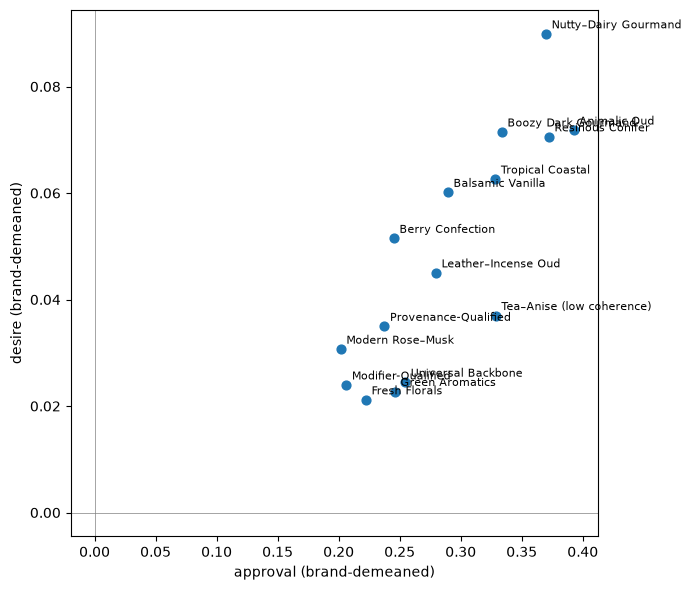

In [19]:
d4f = attach_family(d4[["cluster", "approval_demeaned", "desire_demeaned"]])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(d4f["approval_demeaned"], d4f["desire_demeaned"], s=40)
for _, r in d4f.iterrows():
    ax.annotate(r["Family"], (r["approval_demeaned"], r["desire_demeaned"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("approval (brand-demeaned)")
ax.set_ylabel("desire (brand-demeaned)")
plt.tight_layout()
plt.show()

## 6. Sentiment

Sentiment comes only from Fragrantica's AI-written pros/cons text, matched
against each family's validating accord vocabulary and weighted by net
agreement votes — no external sentiment model. The table compares the
ranking under the original raw net weight against the normalised polarity
ratio actually used in the score: raw weight rewards a family whose accord
words simply appear often in review text regardless of whether the mentions
are positive or negative, so it was replaced with
`(positive - negative) / (positive + negative)`.

In [20]:
t = data["06_territory_scores"]
sent = attach_family(t[["cluster", "sentiment_net_raw", "sentiment_polarity"]])
sent["rank by raw weight"] = sent["sentiment_net_raw"].rank(ascending=False).astype(int)
sent["rank by polarity"] = sent["sentiment_polarity"].rank(ascending=False).astype(int)
show(sent.sort_values("rank by polarity"))

,Family,sentiment_net_raw,sentiment_polarity,rank by raw weight,rank by polarity
6,Berry Confection,89580.0,0.935,3,1
3,Balsamic Vanilla,91119.0,0.890,2,2
0,Nutty–Dairy Gourmand,26933.0,0.882,14,3
1,Tropical Coastal,34424.0,0.879,11,4
13,Fresh Florals,82701.0,0.810,4,5
8,Modern Rose–Musk,106456.0,0.807,1,6
4,Boozy Dark Gourmand,27720.0,0.778,12,7
7,Tea–Anise (low coherence),74650.0,0.768,5,8
14,Universal Backbone,45734.0,0.753,9,9
10,Modifier-Qualified,66151.0,0.749,7,10


## 7. Seasonality

Each family's share of season votes (winter/spring/summer/autumn), weighted
by how much of each product's note profile belongs to that family. Each row
sums to 100% across the four seasons; darker cells mark a family's strongest
season.

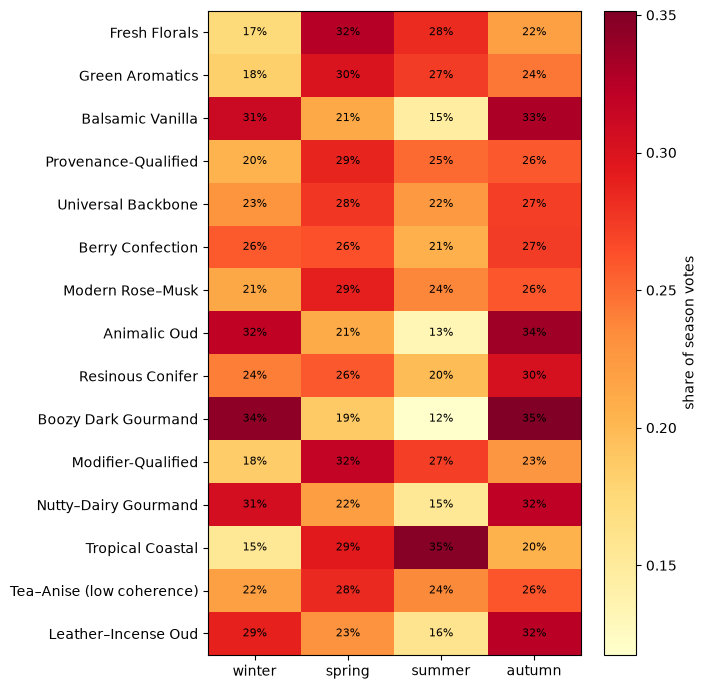

In [21]:
s = attach_family(data["05b_family_season"][
    ["cluster", "winter_share", "spring_share", "summer_share", "autumn_share"]
])
s = s.set_index("Family")[["winter_share", "spring_share", "summer_share", "autumn_share"]]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(s.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["winter", "spring", "summer", "autumn"])
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s.index)
for i in range(s.shape[0]):
    for j in range(s.shape[1]):
        ax.text(j, i, f"{s.values[i, j]:.0%}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="share of season votes")
plt.tight_layout()
plt.show()

## 8. Supply and momentum

Supply is always a *share* of that year's launches, never a raw count — raw
counts rise roughly 9x from 2000 to 2025 because Fragrantica indexes recent
releases far more completely, which is coverage bias, not market growth. The
chart shows the top 8 families by overall share, over time.

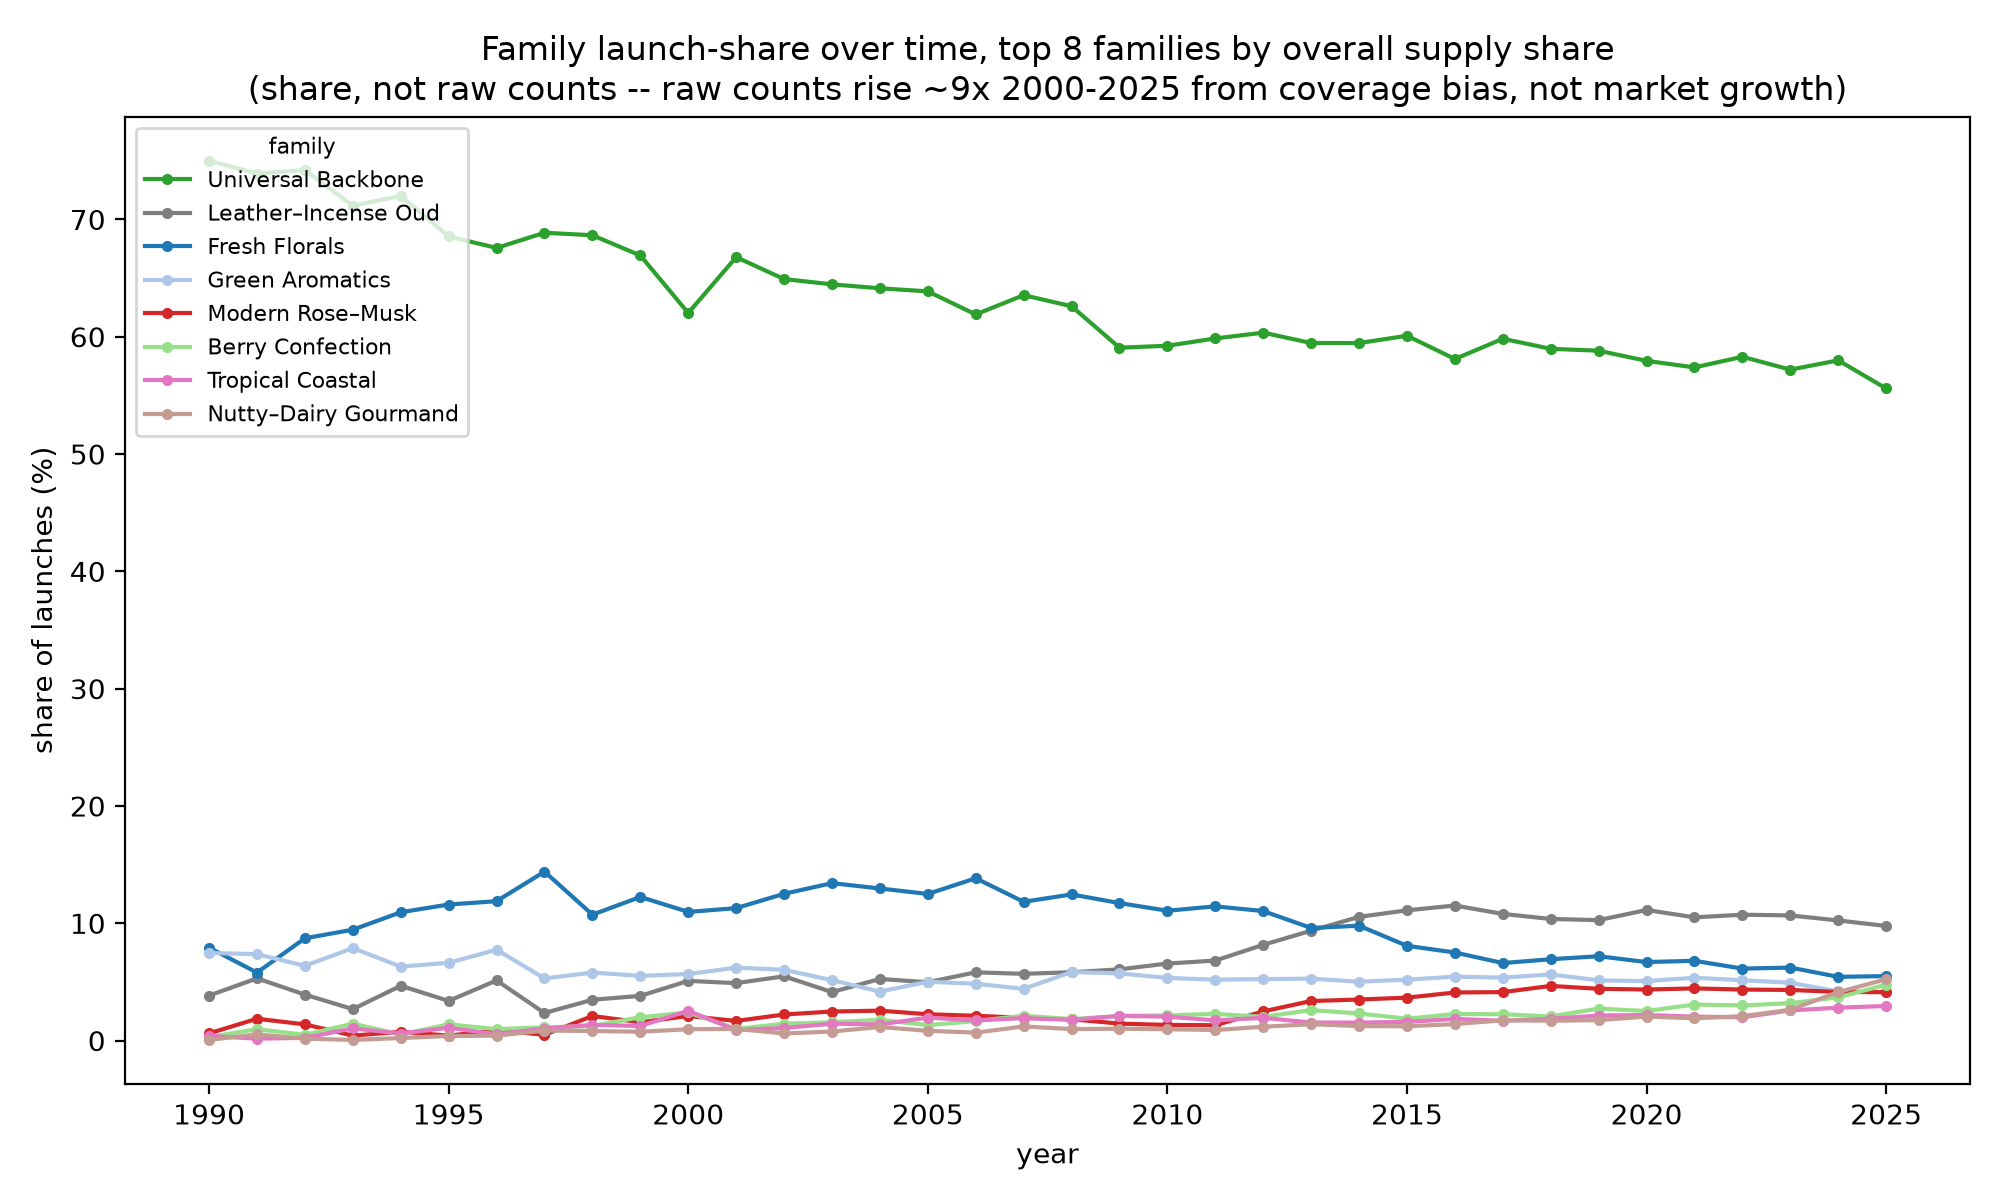

In [22]:
display(Image(filename=str(FIG_DIR / "b_launch_share_over_time.png")))

The table compares mean share in the two fixed 5-year windows the momentum
figure is built from (2015-2019 vs 2020-2024), alongside the saved momentum
value itself (recent minus baseline) that feeds the score.

In [23]:
by_year = data["06_family_share_by_year"]
baseline = by_year[by_year["year"].between(2015, 2019)].groupby("cluster")["supply_share"].mean()
recent = by_year[by_year["year"].between(2020, 2024)].groupby("cluster")["supply_share"].mean()
window = pd.DataFrame({"cluster": baseline.index, "share 2015-19": baseline.values,
                        "share 2020-24": recent.reindex(baseline.index).values})
window = window.merge(data["06_territory_scores"][["cluster", "momentum"]], on="cluster")
show(attach_family(window))

,Family,share 2015-19,share 2020-24,momentum
0,Fresh Florals,0.073,0.063,-0.010
1,Green Aromatics,0.054,0.049,-0.004
2,Balsamic Vanilla,0.005,0.007,0.001
3,Provenance-Qualified,0.018,0.019,0.002
4,Universal Backbone,0.592,0.578,-0.014
5,Berry Confection,0.022,0.031,0.009
6,Modern Rose–Musk,0.042,0.043,0.001
7,Animalic Oud,0.005,0.005,0.000
8,Resinous Conifer,0.008,0.009,0.001
9,Boozy Dark Gourmand,0.018,0.023,0.004


## 9. Territory scores

The full ranking: every demand/supply/sentiment/momentum component, the
composite score, and the confidence tier (from weighted product count —
reported here, never used to filter or adjust the score itself). The
backbone family (near-universal notes, ~59% of all launches) is excluded
from the ranking as table stakes rather than a positioning choice, and
shown separately below.

In [24]:
t = data["06_territory_scores"]
ranked = t[~t["backbone"]].sort_values("score", ascending=False)
cols = ["confidence", "n_products_weighted", "approval_demeaned", "desire_demeaned",
        "sentiment_polarity", "supply_share", "momentum", "score"]
show(attach_family(ranked[["cluster"] + cols]))

backbone_id = int(t.loc[t["backbone"], "cluster"].iloc[0])
print(f"Backbone family (excluded from ranking): {FAMILY[backbone_id]}")

,Family,confidence,n_products_weighted,approval_demeaned,desire_demeaned,sentiment_polarity,supply_share,momentum,score
0,Nutty–Dairy Gourmand,HIGH,616.507,0.370,0.090,0.882,0.019,0.010,5.600
1,Tropical Coastal,HIGH,648.512,0.328,0.063,0.879,0.020,0.005,3.058
2,Animalic Oud,LOW,127.203,0.393,0.072,0.691,0.004,0.000,2.640
3,Balsamic Vanilla,LOW,175.004,0.290,0.060,0.890,0.005,0.001,2.624
4,Boozy Dark Gourmand,HIGH,586.757,0.334,0.071,0.778,0.018,0.004,2.457
5,Resinous Conifer,MEDIUM,245.250,0.372,0.071,0.699,0.008,0.001,2.267
6,Berry Confection,HIGH,834.279,0.245,0.051,0.935,0.026,0.009,1.962
7,Tea–Anise (low coherence),HIGH,614.084,0.329,0.037,0.768,0.019,-0.002,0.023
8,Modern Rose–Musk,HIGH,1138.218,0.202,0.031,0.807,0.035,0.001,-2.188
9,Provenance-Qualified,MEDIUM,472.244,0.238,0.035,0.652,0.015,0.002,-2.267


Backbone family (excluded from ranking): Universal Backbone


The same demand-vs-supply picture as a chart, with the top 3 territories by
score annotated.

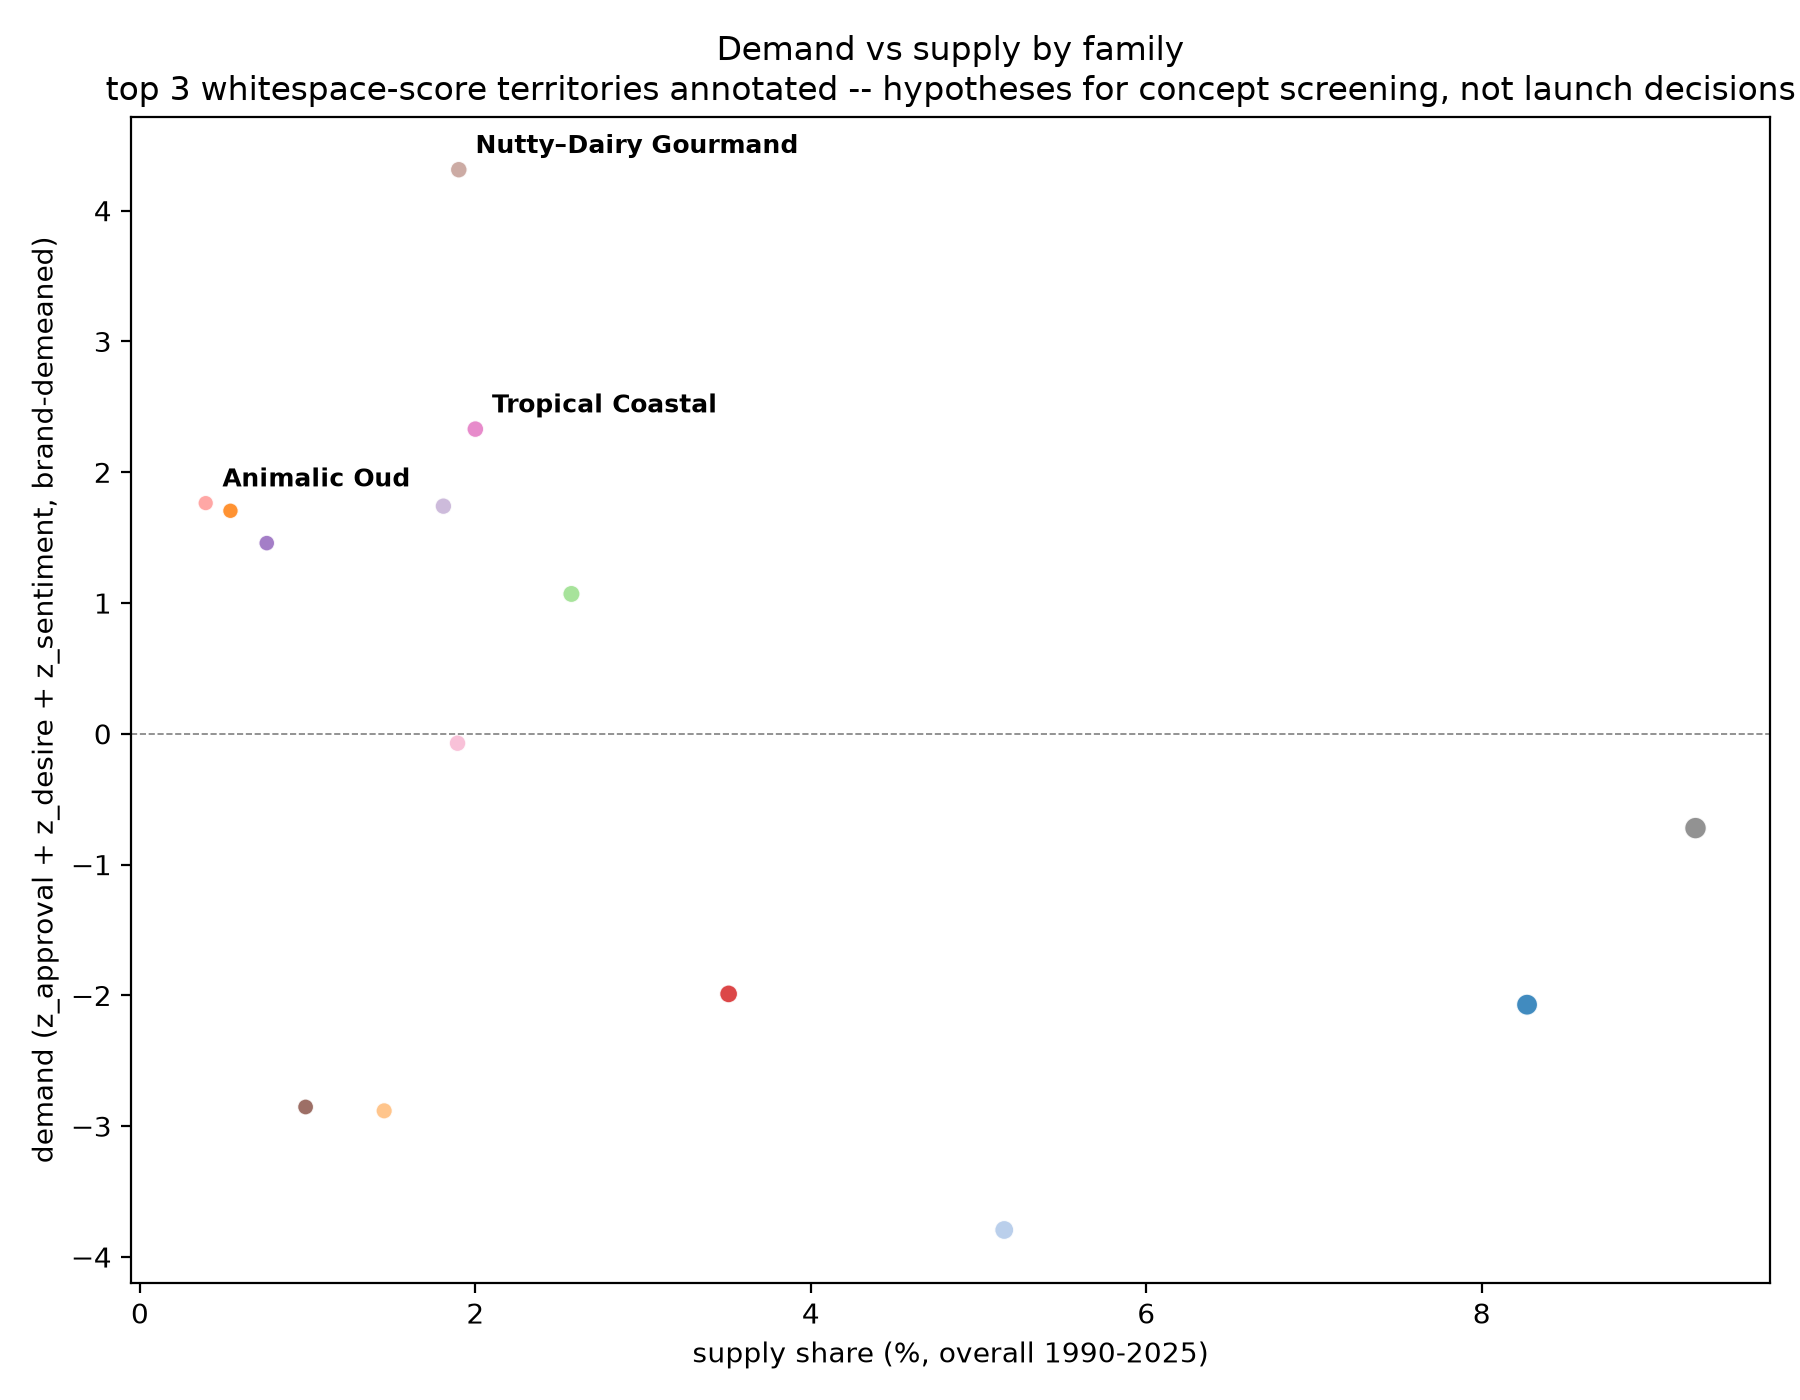

In [25]:
display(Image(filename=str(FIG_DIR / "c_demand_vs_supply.png")))

The score decomposed into its five fixed-weight components per family, so
*why* a family ranks where it does is visible rather than just the total.
Bars are ordered by score, highest at the top; segments left of zero pull
the score down, right of zero push it up.

In [26]:
comp = attach_family(ranked[["cluster", "z_approval", "z_desire", "z_sentiment", "z_supply", "z_momentum"]])
comp["supply penalty"] = -comp["z_supply"]
comp["momentum (x0.5)"] = 0.5 * comp["z_momentum"]
parts = ["z_approval", "z_desire", "z_sentiment", "supply penalty", "momentum (x0.5)"]
plot_df = comp.set_index("Family")[parts].iloc[::-1]

The stacked bars built from those components:

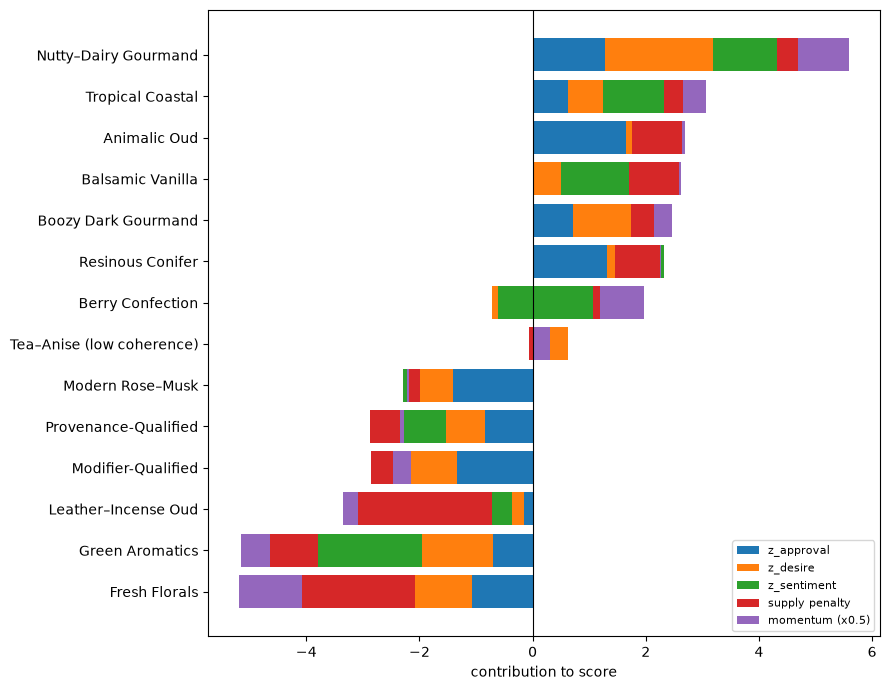

In [27]:
fig, ax = plt.subplots(figsize=(9, 7))
left = np.zeros(len(plot_df))
for part in parts:
    vals = plot_df[part].values
    ax.barh(plot_df.index, vals, left=left, label=part)
    left = left + vals
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("contribution to score")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Three families with the strongest evidence trace

The three families ranked highest by the composite score in section 9, each
with its full evidence trace pulled from the tables already loaded above
(approval, desire, sentiment polarity, supply share, momentum, confidence,
and strongest season). Nothing new is computed here — these are the same
rows shown in sections 5-9, gathered per family in one place.

In [28]:
def evidence_trace(cluster_id):
    row = t[t["cluster"] == cluster_id].iloc[0]
    season = data["05b_family_season"]
    srow = season[season["cluster"] == cluster_id].iloc[0]
    season_cols = ["winter_share", "spring_share", "summer_share", "autumn_share"]
    strongest = srow[season_cols].idxmax().replace("_share", "")
    rank = int(np.where(ranked["cluster"].values == cluster_id)[0][0]) + 1
    r3 = lambda x: round(float(x), 3)
    trace = {
        "Family": FAMILY[cluster_id], "rank": rank,
        "score": r3(row["score"]), "confidence": row["confidence"],
        "approval (demeaned)": r3(row["approval_demeaned"]), "desire (demeaned)": r3(row["desire_demeaned"]),
        "sentiment polarity": r3(row["sentiment_polarity"]), "supply share": r3(row["supply_share"]),
        "momentum": r3(row["momentum"]), "n_products_weighted": r3(row["n_products_weighted"]),
        "strongest season": strongest,
    }
    return pd.Series(trace)

top3_ids = ranked["cluster"].head(3).tolist()
print("Top 3 by score:", [FAMILY[c] for c in top3_ids])

Top 3 by score: ['Nutty–Dairy Gourmand', 'Tropical Coastal', 'Animalic Oud']


### #1 by score

In [29]:
show(evidence_trace(top3_ids[0]).to_frame("value"))

,value
Family,Nutty–Dairy Gourmand
rank,1
score,5.6
confidence,HIGH
approval (demeaned),0.37
desire (demeaned),0.09
sentiment polarity,0.882
supply share,0.019
momentum,0.01
n_products_weighted,616.507


### #2 by score

In [30]:
show(evidence_trace(top3_ids[1]).to_frame("value"))

,value
Family,Tropical Coastal
rank,2
score,3.058
confidence,HIGH
approval (demeaned),0.328
desire (demeaned),0.063
sentiment polarity,0.879
supply share,0.02
momentum,0.005
n_products_weighted,648.512


### #3 by score

In [ ]:
show(evidence_trace(top3_ids[2]).to_frame("value"))